<xarray.Dataset>
Dimensions:     (valid_time: 8456, latitude: 361, longitude: 1440)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 1957-01-01 1957-01-02 ... 2026-03-31
  * latitude    (latitude) float64 90.0 89.75 89.5 89.25 ... 0.75 0.5 0.25 0.0
  * longitude   (longitude) float64 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    expver      (valid_time) object dask.array<chunksize=(365,), meta=np.ndarray>
Data variables:
    msl         (valid_time, latitude, longitude) float32 dask.array<chunksize=(365, 361, 1440), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-15T19:55 GRIB to CDM+CF via cfgrib-0.9.1...
Computing monthly means...
[########################################] | 

/Users/kazimirnyzio/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kazimirnyzio/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kazimirnyzio/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kazimirnyzio/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtoo

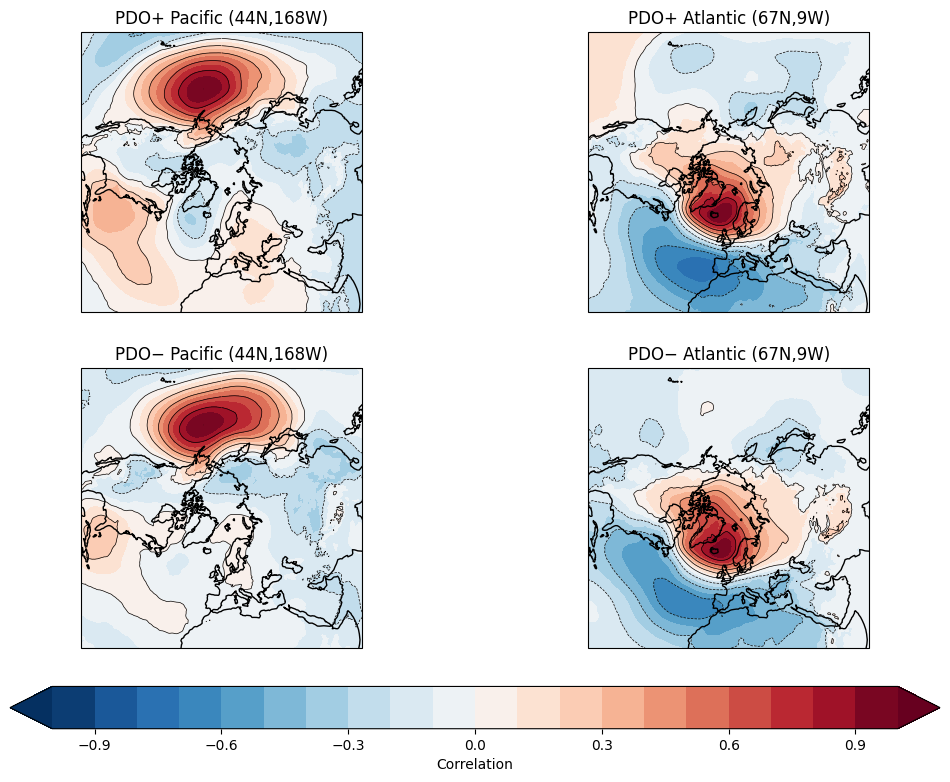


PDO+ covariance:

 [[ 378826.49469753 -339831.10311932  -10867.41926614]
 [-339831.10311932  619274.73107026  -72980.85248126]
 [ -10867.41926614  -72980.85248126  476465.02321847]]
----------------------------------------------------------

PDO- covariance:

 [[ 337089.70735965 -227760.89499472  -11511.7834412 ]
 [-227760.89499472  574002.0893115   -10012.41701853]
 [ -11511.7834412   -10012.41701853  449370.35605891]]
----------------------------------------------------------

For Positive PDO:

EOF1: [-0.56402869  0.81438871 -0.13653818]
Variance explained: 0.58788166195837
EOF2: [-0.1994104   0.02612415  0.97956777]
Variance explained: 0.32330251113142255
EOF3: [0.80131588 0.57973146 0.14766281]
Variance explained: 0.08881582691020766
----------------------------------------------------------

For Negative PDO:

EOF1: [-0.518662    0.85492266 -0.00984739]
Variance explained: 0.5235682109537148
EOF2: [-0.05613833 -0.02256049  0.99816808]
Variance explained: 0.3309493711744833
EOF3:

In [10]:
import xarray as xr
import pandas as pd
from dask.diagnostics import ProgressBar
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Load data with chunking (for progress reports)
ds = xr.open_dataset(
    "DJFM daily mslp Nhem.nc",
    chunks={'valid_time': 365}
)

print(ds)

pdo = pd.read_csv("PDO.csv")

pdo.columns = ['time', 'PDO']

pdo['time'] = pd.to_datetime(pdo['time'])

# Keep DJFM only

pdo = pdo[pdo['time'].dt.month.isin([12, 1, 2, 3])]

pdo = pdo.set_index('time')

# Calculating monthly means 

print("Computing monthly means...")

with ProgressBar():
    ds_monthly = ds.resample(valid_time='1MS').mean().compute()

# Renaming

ds_monthly = ds_monthly.rename({'valid_time': 'time'})

print("Total monthly size (all months):", ds_monthly.time.size)

# Removing seasonality by subtracting climatology 

print("Computing climatology...")
clim = ds_monthly.groupby('time.month').mean('time')

print("Computing anomalies...")
anom = ds_monthly.groupby('time.month') - clim


print("Done with preprocessing.")

# Prepare PDO data array 

pdo_xr = xr.DataArray(pdo['PDO'], coords={'time': pdo.index}, dims='time')

# Allign PDO and AO indices

# Ensure time is datetime
ds = xr.decode_cf(ds)

# Filter NetCDF using PDO time axis
ds = ds.sel(valid_time=ds.valid_time.isin(pdo_xr.time))

# Create masks

pdo_pos = pdo_xr > 0
pdo_neg = pdo_xr < 0

# Filter anomalies

anom_pos = anom.where(pdo_pos, drop=True)
anom_neg = anom.where(pdo_neg, drop=True)

# 7. Check sizes

print("PDO positive DJFM monthly cases:", anom_pos.time.size)
print("PDO negative DJFM monthly cases:",anom.time.size)

# Convert longitudes
lon_pac = -168   # 192
lon_atl = - 9     # 351

lat_pac = 44
lat_atl = 67

# Select nearest grid point
pac_pos = anom_pos['msl'].sel(latitude=lat_pac, longitude=lon_pac, method='nearest')
atl_pos = anom_pos['msl'].sel(latitude=lat_atl, longitude=lon_atl, method='nearest')

pac_neg = anom_neg['msl'].sel(latitude=lat_pac, longitude=lon_pac, method='nearest')
atl_neg = anom_neg['msl'].sel(latitude=lat_atl, longitude=lon_atl, method='nearest')

def local_mean(field, lat, lon, radius=5):
    return field.sel(
        latitude=slice(lat+radius, lat-radius),
        longitude=slice(lon-radius, lon+radius)
    ).mean(dim=['latitude','longitude'])

# Correlation maps 
corr_pac_pos = xr.corr(anom_pos['msl'], pac_pos, dim='time')
corr_atl_pos = xr.corr(anom_pos['msl'], atl_pos, dim='time')

corr_pac_neg = xr.corr(anom_neg['msl'], pac_neg, dim='time')
corr_atl_neg = xr.corr(anom_neg['msl'], atl_neg, dim='time')

print("Correlation map NH grid dimensions (lat, lon):", corr_pac_pos.shape)

# Plotting 

fig, axes = plt.subplots(
    2, 2,
    figsize=(12,10),
    subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

fields = [
    corr_pac_pos, corr_atl_pos,
    corr_pac_neg, corr_atl_neg
]

titles = [
    "PDO+ Pacific (44N,168W)",
    "PDO+ Atlantic (67N,9W)",
    "PDO− Pacific (44N,168W)",
    "PDO− Atlantic (67N,9W)"
]

levels = np.linspace(-1, 1, 21)

for ax, field, title in zip(axes.flat, fields, titles):
    
    ax.set_extent([-180, 180, 20, 90], crs=ccrs.PlateCarree())
    ax.coastlines()
    
    cf = ax.contourf(
        field.longitude,
        field.latitude,
        field,
        levels=levels,
        cmap='RdBu_r',
        extend='both',
        transform=ccrs.PlateCarree()
    )
    
    ax.contour(
        field.longitude,
        field.latitude,
        field,
        levels=np.linspace(-1,1,11),
        colors='black',
        linewidths=0.5,
        transform=ccrs.PlateCarree()
    )
    
    ax.set_title(title)

# Shared colorbar
cbar = fig.colorbar(cf, ax=axes.ravel().tolist(), orientation='horizontal', pad=0.05)
cbar.set_label("Correlation")

plt.show()

# Action Center Covariance Matrices 

az = anom['msl'].sel(latitude=42, longitude=-15, method='nearest')
ic = anom['msl'].sel(latitude=67, longitude=-9, method='nearest')
pa = anom['msl'].sel(latitude=44, longitude=-168, method='nearest')

def local_mean(field, lat, lon, radius=5):
    return field.sel(
        latitude=slice(lat+radius, lat-radius),
        longitude=slice(lon-radius, lon+radius)
    ).mean(dim=['latitude','longitude'])

az = local_mean(anom['msl'], 42, -15)
ic = local_mean(anom['msl'], 67, -9)
pa = local_mean(anom['msl'], 44, -168)

az_pos = az.where(pdo_xr > 0, drop=True)
ic_pos = ic.where(pdo_xr > 0, drop=True)
pa_pos = pa.where(pdo_xr > 0, drop=True)

az_neg = az.where(pdo_xr < 0, drop=True)
ic_neg = ic.where(pdo_xr < 0, drop=True)
pa_neg = pa.where(pdo_xr < 0, drop=True)

def covariance_matrix(a, b, c):
    X = np.vstack([a.values, b.values, c.values])
    return np.cov(X)

C_pos = covariance_matrix(az_pos, ic_pos, pa_pos)
C_neg = covariance_matrix(az_neg, ic_neg, pa_neg)

print("\nPDO+ covariance:\n\n", C_pos)
print("----------------------------------------------------------")
print("\nPDO- covariance:\n\n", C_neg)
print("----------------------------------------------------------")

def eof_analysis(C):
    eigvals, eigvecs = np.linalg.eig(C)
    
    # sort by descending variance
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    
    variance_explained = eigvals / eigvals.sum()
    
    return eigvals, eigvecs, variance_explained

eigvals_pos, eigvecs_pos, var_pos = eof_analysis(C_pos)
eigvals_neg, eigvecs_neg, var_neg = eof_analysis(C_neg)

labels = ["Azores", "Iceland", "Pacific"]

print("\nFor Positive PDO:\n")
for i in range(3):
    print(f"EOF{i+1}:", eigvecs_pos[:, i])
    print(f"Variance explained:", var_pos[i])
print("----------------------------------------------------------")
print("\nFor Negative PDO:\n")
for i in range(3):
    print(f"EOF{i+1}:", eigvecs_neg[:, i])
    print(f"Variance explained:", var_neg[i])